# RoadSafe India — Fatality Trends

## Objective

This notebook analyzes reported road fatalities across Indian States/UTs
from 2020 to 2024.

The analysis focuses on:

1. National fatality trends.
2. Five-year average fatality burden.
3. Change in fatalities from 2020 to 2024.
4. Percentage change in fatalities.
5. Persistence of high fatality rankings across the study period.
6. State-level fatality trends.

Missing values are preserved as missing and are not treated as zero.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fatality_path = (
    "../data/processed/"
    "state_wise_road_fatalities_2020_2024_cleaned.csv"
)

df = pd.read_csv(fatality_path)

print("Fatality dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Fatality dataset loaded successfully.
Rows: 36
Columns: 13


,sl_no,state,2020_killed,2021_killed,2022_killed,2023_killed,2024_killed,percent_change_from_2023_to_2024,2020_ranking,2021_ranking,2022_ranking,2023_ranking,2024_ranking
0,1,Andhra Pradesh,7039.0,8186,8293,8137,8346,2.57,7.0,7.0,8.0,8.0,8.0
1,2,Arunachal Pradesh,73.0,157,148,145,168,15.86,28.0,26.0,27.0,27.0,27.0
2,3,Assam,2629.0,3036,2994,3296,3351,1.67,18.0,18.0,18.0,18.0,18.0
3,4,Bihar,6699.0,7660,8898,8873,9347,5.34,9.0,8.0,7.0,7.0,7.0
4,5,Chhattisgarh,4606.0,5371,5834,6166,6945,12.63,13.0,12.0,12.0,11.0,11.0


In [3]:
year_columns = [
    "2020_killed",
    "2021_killed",
    "2022_killed",
    "2023_killed",
    "2024_killed"
]

years = [2020, 2021, 2022, 2023, 2024]

print("Fatality columns:")
print(year_columns)

Fatality columns:
['2020_killed', '2021_killed', '2022_killed', '2023_killed', '2024_killed']


In [4]:
# Remove rows without a State/UT
state_df = df[
    df["state"].notna()
].copy()

# Remove aggregate records such as "Total (All India)"
state_df = state_df[
    ~state_df["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

print(f"State/UT records used: {len(state_df)}")

State/UT records used: 36


In [5]:
# Remove rows without a State/UT
state_df = df[
    df["state"].notna()
].copy()

# Remove aggregate records such as "Total (All India)"
state_df = state_df[
    ~state_df["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

print(f"State/UT records used: {len(state_df)}")

State/UT records used: 36


In [ ]:
# Calculate national totals for each year.

national_fatalities = state_df[
    year_columns
].sum()

print("Reported fatalities by year:")
display(national_fatalities)

Reported fatalities by year:


2020_killed    138383.0
2021_killed    153972.0
2022_killed    168491.0
2023_killed    172890.0
2024_killed    177175.0
dtype: float64

In [7]:
national_fatalities_df = (
    national_fatalities
    .reset_index()
)

national_fatalities_df.columns = [
    "year",
    "fatalities"
]

national_fatalities_df["year"] = (
    national_fatalities_df["year"]
    .str.replace("_killed", "", regex=False)
    .astype(int)
)

display(national_fatalities_df)

,year,fatalities
0,2020,138383.0
1,2021,153972.0
2,2022,168491.0
3,2023,172890.0
4,2024,177175.0


In [9]:
national_fatalities_df[
    "year_over_year_change_percent"
] = (
    national_fatalities_df["fatalities"]
    .pct_change()
    * 100
)

display(national_fatalities_df)

,year,fatalities,year_over_year_change_percent
0,2020,138383.0,NaN
1,2021,153972.0,11.265112
2,2022,168491.0,9.429637
3,2023,172890.0,2.610822
4,2024,177175.0,2.478455


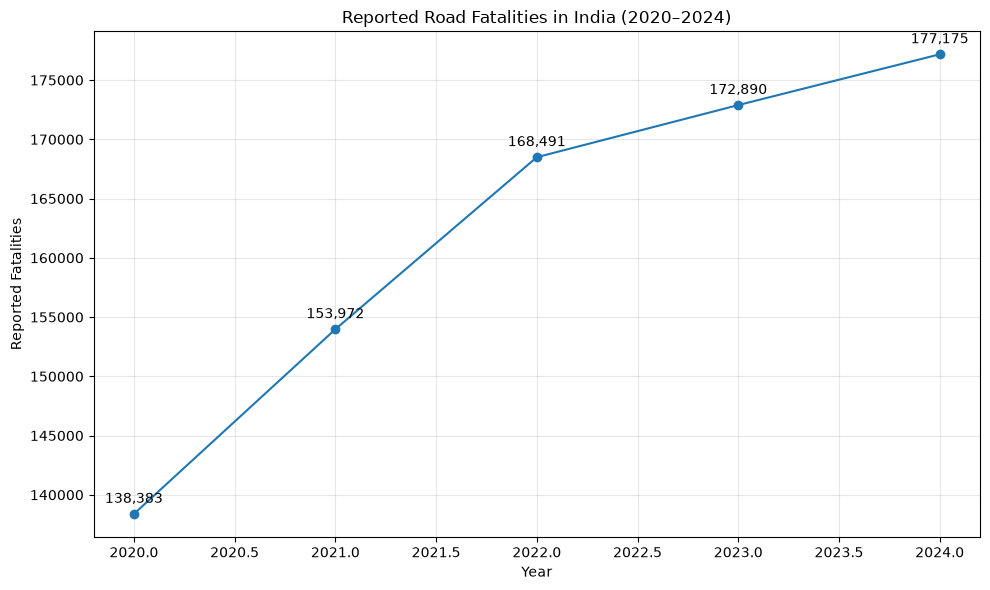

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    national_fatalities_df["year"],
    national_fatalities_df["fatalities"],
    marker="o"
)

plt.title(
    "Reported Road Fatalities in India (2020–2024)"
)

plt.xlabel("Year")
plt.ylabel("Reported Fatalities")

for x, y in zip(
    national_fatalities_df["year"],
    national_fatalities_df["fatalities"]
):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
fatalities_2020 = national_fatalities_df.loc[
    national_fatalities_df["year"] == 2020,
    "fatalities"
].iloc[0]

fatalities_2024 = national_fatalities_df.loc[
    national_fatalities_df["year"] == 2024,
    "fatalities"
].iloc[0]

national_change = (
    fatalities_2024 - fatalities_2020
)

national_percent_change = (
    national_change
    / fatalities_2020
    * 100
)

print(f"2020 reported fatalities: {fatalities_2020:,.0f}")
print(f"2024 reported fatalities: {fatalities_2024:,.0f}")
print(
    f"Absolute change: {national_change:,.0f}"
)
print(
    f"Percentage change: {national_percent_change:.2f}%"
)

2020 reported fatalities: 138,383
2024 reported fatalities: 177,175
Absolute change: 38,792
Percentage change: 28.03%


In [12]:
# Calculate the number of available years for each State/UT

state_df["fatality_years_available"] = (
    state_df[year_columns]
    .notna()
    .sum(axis=1)
)

# Calculate the average across available years

state_df["five_year_average_fatalities"] = (
    state_df[year_columns]
    .mean(axis=1)
)

display(
    state_df[
        [
            "state",
            *year_columns,
            "fatality_years_available",
            "five_year_average_fatalities"
        ]
    ].sort_values(
        "five_year_average_fatalities",
        ascending=False
    ).head(10)
)

,state,2020_killed,2021_killed,2022_killed,2023_killed,2024_killed,fatality_years_available,five_year_average_fatalities
26,Uttar Pradesh,19149.0,21227,22595,23652,24118,5,22148.2
22,Tamil Nadu,14527.0,15384,17884,18347,18449,5,16918.2
13,Maharashtra,11569.0,13528,15224,15366,15715,5,14280.4
12,Madhya Pradesh,11141.0,12057,13427,13798,14791,5,13042.8
10,Karnataka,9760.0,10038,11702,12321,12390,5,11242.2
20,Rajasthan,9250.0,10043,11104,11762,11790,5,10789.8
3,Bihar,6699.0,7660,8898,8873,9347,5,8295.4
0,Andhra Pradesh,7039.0,8186,8293,8137,8346,5,8000.2
23,Telangana,6882.0,7557,7559,7660,7949,5,7521.4
6,Gujarat,6170.0,7452,7618,7854,7717,5,7362.2


In [13]:
state_df["change_2020_to_2024"] = (
    state_df["2024_killed"]
    - state_df["2020_killed"]
)

display(
    state_df[
        [
            "state",
            "2020_killed",
            "2024_killed",
            "change_2020_to_2024"
        ]
    ].sort_values(
        "change_2020_to_2024",
        ascending=False
    ).head(10)
)

,state,2020_killed,2024_killed,change_2020_to_2024
26,Uttar Pradesh,19149.0,24118,4969.0
13,Maharashtra,11569.0,15715,4146.0
22,Tamil Nadu,14527.0,18449,3922.0
12,Madhya Pradesh,11141.0,14791,3650.0
3,Bihar,6699.0,9347,2648.0
10,Karnataka,9760.0,12390,2630.0
20,Rajasthan,9250.0,11790,2540.0
4,Chhattisgarh,4606.0,6945,2339.0
27,West Bengal,5128.0,6676,1548.0
6,Gujarat,6170.0,7717,1547.0


In [14]:
state_df["percent_change_2020_to_2024"] = (
    state_df["change_2020_to_2024"]
    / state_df["2020_killed"]
    * 100
)

display(
    state_df[
        [
            "state",
            "2020_killed",
            "2024_killed",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ].sort_values(
        "percent_change_2020_to_2024",
        ascending=False
    ).head(10)
)

,state,2020_killed,2024_killed,change_2020_to_2024,percent_change_2020_to_2024
16,Mizoram,42.0,110,68.0,161.904762
1,Arunachal Pradesh,73.0,168,95.0,130.136986
28,Andaman & Nicobar Islands,14.0,29,15.0,107.142857
25,Uttarakhand,674.0,1090,416.0,61.721068
4,Chhattisgarh,4606.0,6945,2339.0,50.781589
35,Puducherry,145.0,218,73.0,50.344828
30,Dadra & Nagar Haveli and Daman & Diu,64.0,95,31.0,48.437500
21,Sikkim,47.0,67,20.0,42.553191
29,Chandigarh,53.0,75,22.0,41.509434
3,Bihar,6699.0,9347,2648.0,39.528288


In [15]:
largest_increases = (
    state_df
    .dropna(subset=["change_2020_to_2024"])
    .sort_values(
        "change_2020_to_2024",
        ascending=False
    )
    .head(10)
)

print("Largest absolute increases in reported fatalities:")
display(
    largest_increases[
        [
            "state",
            "2020_killed",
            "2024_killed",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ]
)

Largest absolute increases in reported fatalities:


,state,2020_killed,2024_killed,change_2020_to_2024,percent_change_2020_to_2024
26,Uttar Pradesh,19149.0,24118,4969.0,25.949136
13,Maharashtra,11569.0,15715,4146.0,35.837151
22,Tamil Nadu,14527.0,18449,3922.0,26.998004
12,Madhya Pradesh,11141.0,14791,3650.0,32.761871
3,Bihar,6699.0,9347,2648.0,39.528288
10,Karnataka,9760.0,12390,2630.0,26.946721
20,Rajasthan,9250.0,11790,2540.0,27.459459
4,Chhattisgarh,4606.0,6945,2339.0,50.781589
27,West Bengal,5128.0,6676,1548.0,30.187207
6,Gujarat,6170.0,7717,1547.0,25.072934


In [16]:
largest_decreases = (
    state_df
    .dropna(subset=["change_2020_to_2024"])
    .sort_values(
        "change_2020_to_2024",
        ascending=True
    )
    .head(10)
)

print("Largest absolute decreases in reported fatalities:")
display(
    largest_decreases[
        [
            "state",
            "2020_killed",
            "2024_killed",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ]
)

Largest absolute decreases in reported fatalities:


,state,2020_killed,2024_killed,change_2020_to_2024,percent_change_2020_to_2024
14,Manipur,127.0,72,-55.0,-43.307087
8,Himachal Pradesh,893.0,869,-24.0,-2.687570
34,Lakshadweep,0.0,0,0.0,NaN
17,Nagaland,53.0,62,9.0,16.981132
28,Andaman & Nicobar Islands,14.0,29,15.0,107.142857
21,Sikkim,47.0,67,20.0,42.553191
29,Chandigarh,53.0,75,22.0,41.509434
30,Dadra & Nagar Haveli and Daman & Diu,64.0,95,31.0,48.437500
24,Tripura,192.0,226,34.0,17.708333
15,Meghalaya,144.0,197,53.0,36.805556


In [17]:
top10_counts = {}

for year_column in year_columns:

    yearly_data = state_df[
        ["state", year_column]
    ].dropna()

    yearly_top10 = (
        yearly_data
        .nlargest(10, year_column)
        ["state"]
    )

    for state in yearly_top10:
        top10_counts[state] = (
            top10_counts.get(state, 0) + 1
        )

top10_persistence = (
    pd.DataFrame(
        list(top10_counts.items()),
        columns=[
            "state",
            "years_in_top_10"
        ]
    )
    .sort_values(
        "years_in_top_10",
        ascending=False
    )
    .reset_index(drop=True)
)

display(top10_persistence)

,state,years_in_top_10
0,Uttar Pradesh,5
1,Tamil Nadu,5
2,Maharashtra,5
3,Madhya Pradesh,5
4,Karnataka,5
5,Rajasthan,5
6,Andhra Pradesh,5
7,Telangana,5
8,Bihar,5
9,Gujarat,5


In [18]:
fatality_average_ranking = (
    state_df
    .sort_values(
        "five_year_average_fatalities",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    fatality_average_ranking[
        [
            "state",
            "five_year_average_fatalities",
            "fatality_years_available"
        ]
    ].head(10)
)

,state,five_year_average_fatalities,fatality_years_available
0,Uttar Pradesh,22148.2,5
1,Tamil Nadu,16918.2,5
2,Maharashtra,14280.4,5
3,Madhya Pradesh,13042.8,5
4,Karnataka,11242.2,5
5,Rajasthan,10789.8,5
6,Bihar,8295.4,5
7,Andhra Pradesh,8000.2,5
8,Telangana,7521.4,5
9,Gujarat,7362.2,5


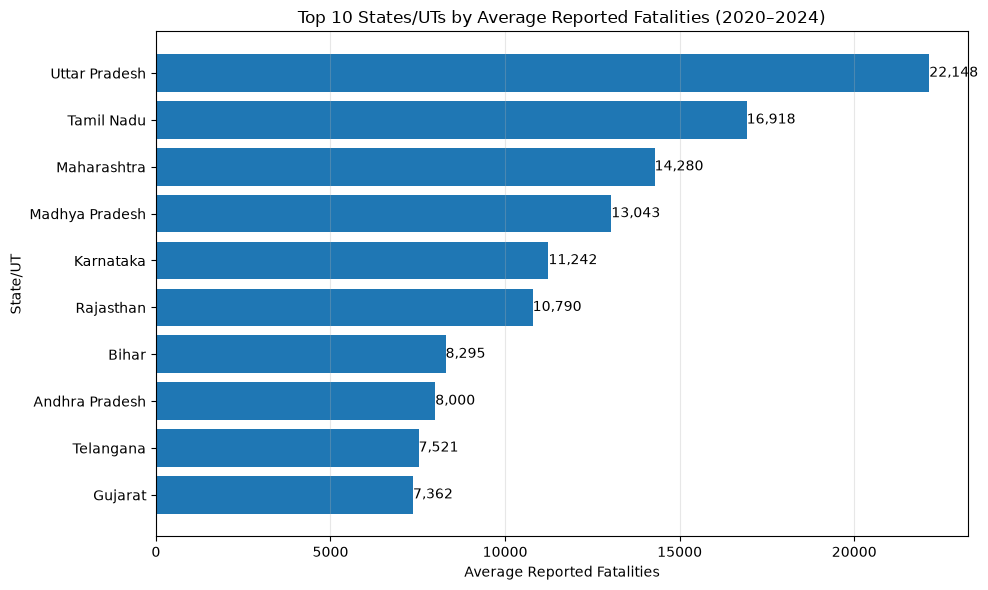

In [19]:
top_average = (
    fatality_average_ranking
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_average["state"],
    top_average["five_year_average_fatalities"]
)

plt.title(
    "Top 10 States/UTs by Average Reported Fatalities (2020–2024)"
)

plt.xlabel("Average Reported Fatalities")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

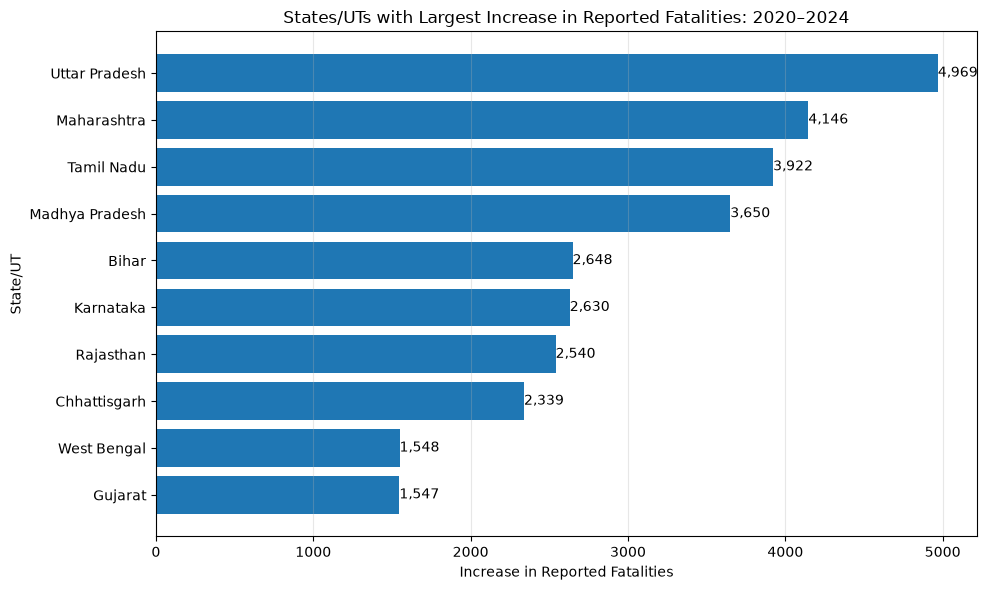

In [20]:
top_increases = (
    largest_increases
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_increases["state"],
    top_increases["change_2020_to_2024"]
)

plt.title(
    "States/UTs with Largest Increase in Reported Fatalities: 2020–2024"
)

plt.xlabel("Increase in Reported Fatalities")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
state_name = "Tamil Nadu"

selected_state = state_df[
    state_df["state"] == state_name
]

trend_df = pd.DataFrame({
    "year": years,
    "fatalities": selected_state[
        year_columns
    ].iloc[0].values
})

display(trend_df)

,year,fatalities
0,2020,14527.0
1,2021,15384.0
2,2022,17884.0
3,2023,18347.0
4,2024,18449.0


In [22]:
fatality_trend_table = state_df[
    [
        "state",
        "2020_killed",
        "2021_killed",
        "2022_killed",
        "2023_killed",
        "2024_killed",
        "fatality_years_available",
        "five_year_average_fatalities",
        "change_2020_to_2024",
        "percent_change_2020_to_2024"
    ]
].copy()

display(
    fatality_trend_table.sort_values(
        "five_year_average_fatalities",
        ascending=False
    ).head(15)
)

,state,2020_killed,2021_killed,2022_killed,2023_killed,2024_killed,fatality_years_available,five_year_average_fatalities,change_2020_to_2024,percent_change_2020_to_2024
26,Uttar Pradesh,19149.0,21227,22595,23652,24118,5,22148.2,4969.0,25.949136
22,Tamil Nadu,14527.0,15384,17884,18347,18449,5,16918.2,3922.0,26.998004
13,Maharashtra,11569.0,13528,15224,15366,15715,5,14280.4,4146.0,35.837151
12,Madhya Pradesh,11141.0,12057,13427,13798,14791,5,13042.8,3650.0,32.761871
10,Karnataka,9760.0,10038,11702,12321,12390,5,11242.2,2630.0,26.946721
20,Rajasthan,9250.0,10043,11104,11762,11790,5,10789.8,2540.0,27.459459
3,Bihar,6699.0,7660,8898,8873,9347,5,8295.4,2648.0,39.528288
0,Andhra Pradesh,7039.0,8186,8293,8137,8346,5,8000.2,1307.0,18.567978
23,Telangana,6882.0,7557,7559,7660,7949,5,7521.4,1067.0,15.504214
6,Gujarat,6170.0,7452,7618,7854,7717,5,7362.2,1547.0,25.072934


In [23]:
output_path = (
    "../data/processed/"
    "state_fatality_trends_2020_2024.csv"
)

fatality_trend_table.to_csv(
    output_path,
    index=False
)

print("Fatality trend dataset saved:")
print(output_path)

Fatality trend dataset saved:
../data/processed/state_fatality_trends_2020_2024.csv


In [24]:
output_path = (
    "../data/processed/"
    "state_fatality_trends_2020_2024.csv"
)

fatality_trend_table.to_csv(
    output_path,
    index=False
)

print("Fatality trend dataset saved:")
print(output_path)

Fatality trend dataset saved:
../data/processed/state_fatality_trends_2020_2024.csv


## Initial Findings

The five-year fatality analysis provides a temporal perspective on India's
road-safety burden.

The analysis distinguishes between:

- Absolute fatality burden.
- Average fatality burden across available years.
- Change between 2020 and 2024.
- Persistence of high fatality rankings.

The analysis does not treat missing fatality values as zero. Ladakh's missing
2020 fatality value is retained as unavailable, so calculations requiring a
2020 baseline exclude Ladakh.

The 2020–2024 period should be interpreted carefully because 2020 and 2021
were affected by exceptional mobility conditions.

Changes in reported fatalities should therefore not automatically be
interpreted as changes in underlying road-safety risk.

## Key Findings

The fatality trend analysis shows a strong persistence of high reported
fatality burden across the study period.

The same ten States/UTs — Uttar Pradesh, Tamil Nadu, Maharashtra, Madhya
Pradesh, Karnataka, Rajasthan, Andhra Pradesh, Telangana, Bihar and Gujarat —
appear in the top ten fatality ranking in every year from 2020 through 2024.

Uttar Pradesh recorded the highest reported fatality count throughout the
period and increased from 19,149 reported fatalities in 2020 to 24,118 in
2024.

The persistence of these States/UTs suggests that India's reported fatality
burden is concentrated in a relatively stable group of States/UTs rather than
being driven by entirely different States each year.

However, persistence in reported fatality rankings does not establish the
causes of the observed burden. Population, traffic exposure, road
characteristics, reporting practices and other contextual factors may all
contribute.